# QPIE Phase 7 — BloodMNIST Classification
## Does entangling colour-channel qubits improve quantum image features?

BloodMNIST: 8-class blood cell microscopy (28×28 RGB).  
Cell types distinguished primarily by **staining colour** — exactly the inter-channel
relationships that entanglement between R/G/B qubits should capture.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from medmnist import BloodMNIST
import time, warnings
warnings.filterwarnings('ignore')

# ── Load BloodMNIST (8-class, 28×28 RGB) ──────────────────
train_ds = BloodMNIST(split='train', download=True, size=28)
test_ds  = BloodMNIST(split='test',  download=True, size=28)

X_train = train_ds.imgs           # uint8
y_train = train_ds.labels.ravel()
X_test  = test_ds.imgs
y_test  = test_ds.labels.ravel()

class_names = ['BAS','EOS','ERY','IG','LYM','MON','NEU','PLT']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {len(np.unique(y_train))} — {class_names}")
print(f"Train distribution: {np.bincount(y_train)}")

flat = X_train.reshape(-1, 3).astype(float)
C = np.corrcoef(flat.T)
print(f"\nGlobal channel correlations:")
print(f"  ρ(R,G) = {C[0,1]:.3f}")
print(f"  ρ(G,B) = {C[1,2]:.3f}")
print(f"  ρ(R,B) = {C[0,2]:.3f}")

Train: (11959, 28, 28, 3), Test: (3421, 28, 28, 3)
Classes: 8 — ['BAS', 'EOS', 'ERY', 'IG', 'LYM', 'MON', 'NEU', 'PLT']
Train distribution: [ 852 2181 1085 2026  849  993 2330 1643]

Global channel correlations:
  ρ(R,G) = 0.991
  ρ(G,B) = 0.859
  ρ(R,B) = 0.856


In [2]:
# ==================================================================
# Encoding functions + multi-basis measurement
# ==================================================================

def _theta(rgb):
    return rgb.astype(np.float64) / 255.0 * (np.pi / 2)

# --- Separable (product state) ---
def _amps_sep(rgb):
    t = _theta(rgb); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([cR*cG*cB, sR*cG*cB, cR*sG*cB, sR*sG*cB,
                            cR*cG*sB, sR*cG*sB, cR*sG*sB, sR*sG*sB])

# --- CRyE (Controlled-Ry(pi) Cascade Entanglement) ---
def _amps_crye(rgb):
    t = _theta(rgb); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([ cR*cG*cB, -sR*sG*cB, -cR*sG*sB, -sR*cG*sB,
                             cR*cG*sB, -sR*sG*sB,  cR*sG*cB,  sR*cG*cB])

# --- GBE (GHZ-Basis Entanglement) ---
def _amps_gbe(rgb):
    t = _theta(rgb); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([
        cR*cG*cB-sR*sG*sB, sR*cG*cB+cR*sG*sB, cR*sG*cB+sR*cG*sB, sR*sG*cB-cR*cG*sB,
        cR*cG*sB+sR*sG*cB, sR*cG*sB-cR*sG*cB, cR*sG*sB-sR*cG*cB, sR*sG*sB+cR*cG*cB
    ]) / np.sqrt(2)

# --- CSE v2 (encode-then-entangle, per-image correlation) ---
def _amps_cse(rgb, rho_rg, rho_gb):
    t = _theta(rgb)
    cR,sR = np.cos(t[:,0]),np.sin(t[:,0])
    cG,sG = np.cos(t[:,1]),np.sin(t[:,1])
    cB,sB = np.cos(t[:,2]),np.sin(t[:,2])
    a_rg, a_gb = rho_rg*np.pi/2, rho_gb*np.pi/2
    cGe,sGe = np.cos(t[:,1]+a_rg), np.sin(t[:,1]+a_rg)
    cBe,sBe = np.cos(t[:,2]+a_gb), np.sin(t[:,2]+a_gb)
    return np.column_stack([cR*cG*cB,  sR*cGe*cB, cR*sG*cBe, sR*sGe*cBe,
                            cR*cG*sB,  sR*cGe*sB, cR*sG*sBe, sR*sGe*sBe])

# --- Pixel-Adaptive CSE ---
def _amps_pa_cse(rgb):
    t = _theta(rgb)
    cR,sR = np.cos(t[:,0]), np.sin(t[:,0])
    cG,sG = np.cos(t[:,1]), np.sin(t[:,1])
    cB,sB = np.cos(t[:,2]), np.sin(t[:,2])
    norm = rgb.astype(np.float64) / 255.0
    a_rg = norm[:,0] * norm[:,1] * np.pi / 2
    a_gb = norm[:,1] * norm[:,2] * np.pi / 2
    cGe,sGe = np.cos(t[:,1]+a_rg), np.sin(t[:,1]+a_rg)
    cBe,sBe = np.cos(t[:,2]+a_gb), np.sin(t[:,2]+a_gb)
    return np.column_stack([cR*cG*cB, sR*cGe*cB, cR*sG*cBe, sR*sGe*cBe,
                            cR*cG*sB, sR*cGe*sB, cR*sG*sBe, sR*sGe*sBe])

# --- Gate primitives for circuit simulation ---
def apply_ry(state, theta, q):
    c = np.cos(theta/2); s = np.sin(theta/2)
    new = state.copy(); stride = 1 << q
    for a in range(8):
        if a & stride == 0:
            b = a + stride
            new[:, a] = c * state[:, a] - s * state[:, b]
            new[:, b] = s * state[:, a] + c * state[:, b]
    return new

def apply_crz(state, alpha, ctrl, tgt):
    new = state.copy(); cs, ts = 1 << ctrl, 1 << tgt
    p_neg, p_pos = np.exp(-1j * alpha / 2), np.exp(1j * alpha / 2)
    for idx in range(8):
        if idx & cs:
            new[:, idx] = (p_pos if idx & ts else p_neg) * state[:, idx]
    return new

def init_state(N):
    s = np.zeros((N, 8), dtype=complex); s[:, 0] = 1.0; return s

# --- CP-2L: 2-layer data re-uploading ---
def _amps_cp_2L(rgb):
    t = _theta(rgb); N = len(t); s = init_state(N)
    for layer, perm in enumerate([(0,1,2), (2,0,1)]):
        s = apply_ry(s, t[:,perm[0]], 0)
        s = apply_ry(s, t[:,perm[1]], 1)
        s = apply_ry(s, t[:,perm[2]], 2)
        s = apply_crz(s, t[:,perm[0]]*t[:,perm[1]], 0, 1)
        s = apply_crz(s, t[:,perm[1]]*t[:,perm[2]], 1, 2)
        s = apply_crz(s, t[:,perm[0]]*t[:,perm[2]], 0, 2)
    return s

# --- Multi-basis measurement ---
_H = np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)
_HSd = np.array([[1,-1j],[1,1j]], dtype=complex) / np.sqrt(2)

def _kron_n(M, n):
    R = M
    for _ in range(n-1): R = np.kron(R, M)
    return R

_V = {
    3: [np.eye(8,dtype=complex), _kron_n(_H,3), _kron_n(_HSd,3)],
    2: [np.eye(4,dtype=complex), _kron_n(_H,2), _kron_n(_HSd,2)],
}

def multi_basis(amps, nq=3):
    return np.hstack([np.abs(amps @ V.T)**2 for V in _V[nq]])

In [3]:
# ==================================================================
# Feature extraction: all schemes
# ==================================================================
N_tr, N_te = len(X_train), len(X_test)
schemes = {}

# Classical baseline
schemes['Raw RGB'] = (X_train.reshape(N_tr,-1).astype(np.float32),
                      X_test.reshape(N_te,-1).astype(np.float32))

def _ext(X, fn, nq, mb):
    a = fn(X.reshape(-1,3))
    f = multi_basis(a, nq) if mb else np.abs(a)**2
    return f.reshape(len(X), -1).astype(np.float32)

def _ext_cse(X, mb):
    N = len(X); d = (24 if mb else 8)
    out = np.empty((N, 784*d), dtype=np.float32)
    for i in range(N):
        px = X[i].reshape(-1,3).astype(float)
        c = np.corrcoef(px.T)
        rg = np.clip(abs(c[0,1]),0.01,0.99)
        gb = np.clip(abs(c[1,2]),0.01,0.99)
        a = _amps_cse(px, rg, gb)
        out[i] = (multi_basis(a,3) if mb else a**2).ravel()
    return out

configs = [
    ('Sep (Z)',         _amps_sep,    3, False),
    ('Sep (Z+X+Y)',     _amps_sep,    3, True),
    ('CRyE (Z+X+Y)',     _amps_crye,    3, True),
    ('GBE (Z+X+Y)',  _amps_gbe,   3, True),
    ('CSE (Z)',         'cse',         3, False),
    ('CSE (Z+X+Y)',     'cse',         3, True),
    ('PA-CSE (Z+X+Y)',  _amps_pa_cse, 3, True),
    ('CP-2L (Z+X+Y)',   _amps_cp_2L,  3, True),
]

print("Extracting features...")
for label, fn, nq, mb in configs:
    t0 = time.time()
    if fn == 'cse':
        tr, te = _ext_cse(X_train, mb), _ext_cse(X_test, mb)
    else:
        tr, te = _ext(X_train,fn,nq,mb), _ext(X_test,fn,nq,mb)
    schemes[label] = (tr, te)
    print(f"  {label:20s} {tr.shape[1]:>6d} features  {time.time()-t0:.1f}s")
print("Done.")

Extracting features...
  Sep (Z)                6272 features  1.1s
  Sep (Z+X+Y)           18816 features  3.3s
  CRyE (Z+X+Y)          18816 features  2.5s
  GBE (Z+X+Y)           18816 features  4.3s
  CSE (Z)                6272 features  1.1s
  CSE (Z+X+Y)           18816 features  2.6s
  PA-CSE (Z+X+Y)        18816 features  4.8s
  CP-2L (Z+X+Y)         18816 features  13.6s
Done.


In [4]:
# ==================================================================
# Aggregated features + MLP classification
# ==================================================================
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis

y_tr, y_te = y_train, y_test
n_classes = len(class_names)

def agg(X_flat, npix=784):
    N = len(X_flat); d = X_flat.shape[1] // npix
    P = X_flat.reshape(N, npix, d)
    mu = P.mean(1); std = P.std(1)
    sk = skew(P, axis=1); ku = kurtosis(P, axis=1)
    P_c = P - P.mean(1, keepdims=True)
    norms = np.sqrt((P_c**2).sum(1, keepdims=True) + 1e-10)
    P_n = P_c / norms
    C = np.einsum('npi,npj->nij', P_n, P_n) / npix
    ii, jj = np.triu_indices(d, k=1)
    corr = C[:, ii, jj]
    return np.nan_to_num(np.hstack([mu, std, sk, ku, corr]).astype(np.float32))

print(f"{'Scheme':22s} {'Raw-D':>6s} {'Agg-D':>6s}  {'MLP-BA':>7s}   ", "  ".join(f"{c:>5s}" for c in class_names))
print("-" * 120)

results = {}
for name, (Xtr, Xte) in schemes.items():
    Atr, Ate = agg(Xtr), agg(Xte)
    sc = StandardScaler()
    Ztr, Zte = sc.fit_transform(Atr), sc.transform(Ate)
    clf = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=42, early_stopping=True)
    clf.fit(Ztr, y_tr)
    pred = clf.predict(Zte)
    ba = balanced_accuracy_score(y_te, pred)
    cm = confusion_matrix(y_te, pred, labels=np.arange(n_classes))
    rec = cm.diagonal() / cm.sum(axis=1)
    results[name] = dict(ba=ba, rec=rec, d_raw=Xtr.shape[1], d_agg=Atr.shape[1])
    print(f"{name:22s} {Xtr.shape[1]:>6d} {Atr.shape[1]:>6d}  {ba:.4f}   ", "  ".join(f"{r:.3f}" for r in rec))

Scheme                  Raw-D  Agg-D   MLP-BA      BAS    EOS    ERY     IG    LYM    MON    NEU    PLT
------------------------------------------------------------------------------------------------------------------------
Raw RGB                  2352     15  0.8747    0.738  0.981  0.926  0.781  0.881  0.746  0.947  0.998
Sep (Z)                  6272     60  0.9312    0.848  0.998  0.949  0.845  0.938  0.908  0.965  0.998
Sep (Z+X+Y)             18816    372  0.9350    0.840  0.994  0.955  0.879  0.947  0.915  0.950  1.000
CRyE (Z+X+Y)            18816    372  0.9227    0.824  0.987  0.949  0.857  0.914  0.891  0.961  1.000
GBE (Z+X+Y)             18816    372  0.9239    0.811  0.990  0.958  0.865  0.909  0.894  0.964  0.998
CSE (Z)                  6272     60  0.9289    0.852  0.990  0.952  0.841  0.934  0.905  0.956  1.000
CSE (Z+X+Y)             18816    372  0.9176    0.828  0.987  0.942  0.867  0.905  0.870  0.941  1.000
PA-CSE (Z+X+Y)          18816    372  0.9387    0.857 

In [5]:
# ==================================================================
# Rigorous comparison: classical nonlinear baselines + statistical significance
# ==================================================================
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import PolynomialFeatures
from scipy.stats import skew, kurtosis
import time

y_tr, y_te = y_train, y_test
n_classes = len(class_names)
N_SEEDS = 10

def agg(X_flat, npix=784):
    N = len(X_flat); d = X_flat.shape[1] // npix
    P = X_flat.reshape(N, npix, d)
    mu = P.mean(1); std = P.std(1)
    sk = skew(P, axis=1); ku = kurtosis(P, axis=1)
    P_c = P - P.mean(1, keepdims=True)
    norms = np.sqrt((P_c**2).sum(1, keepdims=True) + 1e-10)
    P_n = P_c / norms
    C = np.einsum('npi,npj->nij', P_n, P_n) / npix
    ii, jj = np.triu_indices(d, k=1)
    corr = C[:, ii, jj]
    return np.nan_to_num(np.hstack([mu, std, sk, ku, corr]).astype(np.float32))

# --- Classical nonlinear baselines at matched dimensions ---
# 1. RBF Random Fourier Features on raw RGB pixels
X_tr_flat = X_train.reshape(len(X_train), -1).astype(np.float32) / 255.0
X_te_flat = X_test.reshape(len(X_test), -1).astype(np.float32) / 255.0

# RBF: expand to 8 components per pixel (match Sep Z), then aggregate
rbf = RBFSampler(n_components=8, gamma=1.0, random_state=42)
rbf.fit(X_train.reshape(-1, 3).astype(np.float32) / 255.0)
rbf_tr = rbf.transform(X_train.reshape(-1, 3).astype(np.float32) / 255.0).reshape(len(X_train), -1).astype(np.float32)
rbf_te = rbf.transform(X_test.reshape(-1, 3).astype(np.float32) / 255.0).reshape(len(X_test), -1).astype(np.float32)

# 2. Polynomial features (degree 2) on per-pixel RGB -> 10 components per pixel
poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(X_train.reshape(-1, 3).astype(np.float32) / 255.0)
poly_tr = poly.transform(X_train.reshape(-1, 3).astype(np.float32) / 255.0).reshape(len(X_train), -1).astype(np.float32)
poly_te = poly.transform(X_test.reshape(-1, 3).astype(np.float32) / 255.0).reshape(len(X_test), -1).astype(np.float32)

# 3. RBF with 24 components (match Z+X+Y quantum schemes)
rbf24 = RBFSampler(n_components=24, gamma=1.0, random_state=42)
rbf24.fit(X_train.reshape(-1, 3).astype(np.float32) / 255.0)
rbf24_tr = rbf24.transform(X_train.reshape(-1, 3).astype(np.float32) / 255.0).reshape(len(X_train), -1).astype(np.float32)
rbf24_te = rbf24.transform(X_test.reshape(-1, 3).astype(np.float32) / 255.0).reshape(len(X_test), -1).astype(np.float32)

# Add classical baselines to schemes
classical_baselines = {
    'Raw RGB (scaled)': (X_tr_flat, X_te_flat),
    'RBF-8 (classical)': (rbf_tr, rbf_te),
    'RBF-24 (classical)': (rbf24_tr, rbf24_te),
    'Poly-2 (classical)': (poly_tr, poly_te),
}

# --- Multi-seed evaluation ---
all_schemes = {}
all_schemes.update(classical_baselines)
# Add quantum schemes from cell 3
for name in ['Sep (Z)', 'Sep (Z+X+Y)', 'CRyE (Z+X+Y)', 'GBE (Z+X+Y)',
             'CSE (Z)', 'CSE (Z+X+Y)', 'PA-CSE (Z+X+Y)', 'CP-2L (Z+X+Y)']:
    if name in schemes:
        all_schemes[name] = schemes[name]

print(f"{'Scheme':25s} {'Agg-D':>6s}  {'Mean BA':>8s} {'±Std':>7s}  {'Min':>6s}  {'Max':>6s}  seeds={N_SEEDS}")
print("=" * 80)

summary = {}
for name, (Xtr, Xte) in all_schemes.items():
    Atr, Ate = agg(Xtr), agg(Xte)
    bas = []
    for seed in range(N_SEEDS):
        sc = StandardScaler()
        Ztr, Zte = sc.fit_transform(Atr), sc.transform(Ate)
        clf = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300,
                           random_state=seed, early_stopping=True)
        clf.fit(Ztr, y_tr)
        pred = clf.predict(Zte)
        bas.append(balanced_accuracy_score(y_te, pred))
    mu, std = np.mean(bas), np.std(bas)
    summary[name] = dict(mean=mu, std=std, min=min(bas), max=max(bas), d=Atr.shape[1])
    tag = ""
    if "classical" in name or "Raw" in name or "Poly" in name:
        tag = " ← CLASSICAL"
    print(f"{name:25s} {Atr.shape[1]:>6d}  {mu:.4f}  ±{std:.4f}  {min(bas):.4f}  {max(bas):.4f}{tag}")

# --- Fair head-to-head at equal dimensions ---
print()
print("=" * 80)
print("FAIR COMPARISON: Equal aggregated dimensions (372)")
print("=" * 80)
fair = {k: v for k, v in summary.items() if v['d'] == 372}
for name, v in sorted(fair.items(), key=lambda x: -x[1]['mean']):
    tag = " ← CLASSICAL" if "classical" in name or "Poly" in name else ""
    print(f"  {name:25s}  {v['mean']:.4f} ± {v['std']:.4f}{tag}")

print()
print("=" * 80)
print("FAIR COMPARISON: Equal aggregated dimensions (60)")
print("=" * 80)
fair60 = {k: v for k, v in summary.items() if v['d'] == 60}
for name, v in sorted(fair60.items(), key=lambda x: -x[1]['mean']):
    tag = " ← CLASSICAL" if "classical" in name or "RBF" in name else ""
    print(f"  {name:25s}  {v['mean']:.4f} ± {v['std']:.4f}{tag}")

Scheme                     Agg-D   Mean BA    ±Std     Min     Max  seeds=10
Raw RGB (scaled)              15  0.8739  ±0.0052  0.8654  0.8824 ← CLASSICAL
RBF-8 (classical)             60  0.8984  ±0.0030  0.8933  0.9035 ← CLASSICAL
RBF-24 (classical)           372  0.9221  ±0.0052  0.9131  0.9318 ← CLASSICAL
Poly-2 (classical)            72  0.9024  ±0.0077  0.8859  0.9128 ← CLASSICAL
Sep (Z)                       60  0.9270  ±0.0026  0.9233  0.9310
Sep (Z+X+Y)                  372  0.9360  ±0.0053  0.9215  0.9419
CRyE (Z+X+Y)                 372  0.9283  ±0.0049  0.9185  0.9354
GBE (Z+X+Y)                  372  0.9279  ±0.0051  0.9219  0.9360
CSE (Z)                       60  0.9239  ±0.0033  0.9188  0.9279
CSE (Z+X+Y)                  372  0.9309  ±0.0030  0.9257  0.9353
PA-CSE (Z+X+Y)               372  0.9309  ±0.0038  0.9208  0.9345
CP-2L (Z+X+Y)                372  0.9312  ±0.0054  0.9221  0.9436

FAIR COMPARISON: Equal aggregated dimensions (372)
  Sep (Z+X+Y)                0.

In [6]:
# ==================================================================
# SOTA Comparison: ACC + AUC + Bigger MLPs + PyTorch GPU
# ==================================================================
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler, label_binarize
from scipy.stats import skew, kurtosis
import time

y_tr, y_te = y_train, y_test
n_classes = len(class_names)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

def agg(X_flat, npix=784):
    N = len(X_flat); d = X_flat.shape[1] // npix
    P = X_flat.reshape(N, npix, d)
    mu = P.mean(1); std = P.std(1)
    sk = skew(P, axis=1); ku = kurtosis(P, axis=1)
    P_c = P - P.mean(1, keepdims=True)
    norms = np.sqrt((P_c**2).sum(1, keepdims=True) + 1e-10)
    P_n = P_c / norms
    C = np.einsum('npi,npj->nij', P_n, P_n) / npix
    ii, jj = np.triu_indices(d, k=1)
    corr = C[:, ii, jj]
    return np.nan_to_num(np.hstack([mu, std, sk, ku, corr]).astype(np.float32))

def train_gpu_mlp(Xtr, ytr, Xte, yte, hidden=256, epochs=150, lr=1e-3):
    d = Xtr.shape[1]
    mu, std = Xtr.mean(0), Xtr.std(0) + 1e-8
    Xtr_n = (Xtr - mu) / std
    Xte_n = (Xte - mu) / std
    train_ds = TensorDataset(torch.tensor(Xtr_n, dtype=torch.float32),
                             torch.tensor(ytr, dtype=torch.long))
    loader = DataLoader(train_ds, batch_size=512, shuffle=True)
    model = nn.Sequential(
        nn.Linear(d, hidden), nn.ReLU(), nn.BatchNorm1d(hidden), nn.Dropout(0.3),
        nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(hidden//2, n_classes)
    ).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
        scheduler.step()
    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(Xte_n, dtype=torch.float32).to(device)
        logits = model(Xt)
        pred = logits.argmax(dim=1).cpu().numpy()
        probs = torch.softmax(logits, dim=1).cpu().numpy()
    return pred, probs

# --- Test schemes ---
test_schemes = ['Raw RGB', 'Sep (Z)', 'Sep (Z+X+Y)', 'PA-CSE (Z+X+Y)', 'CP-2L (Z+X+Y)',
                'CSE (Z+X+Y)', 'CRyE (Z+X+Y)']
test_schemes = [s for s in test_schemes if s in schemes]

# SOTA reference
print("SOTA (MedMNIST v2 BloodMNIST):")
print("  ResNet-18 (28):      ACC=0.958  AUC=0.998")
print("  ResNet-18 (224):     ACC=0.963  AUC=0.998")
print("  Google AutoML:       ACC=0.966  AUC=0.998")
print()

y_te_bin = label_binarize(y_te, classes=np.arange(n_classes))

# A: Aggregated features + sklearn MLP (various sizes)
print("=" * 85)
print("A) AGGREGATED FEATURES + sklearn MLP")
print(f"{'Scheme':22s} {'Agg-D':>6s}  {'BA':>6s}  {'ACC':>6s}  {'AUC':>6s}  MLP size")
print("-" * 85)

for name in test_schemes:
    Xtr, Xte = schemes[name]
    Atr, Ate = agg(Xtr), agg(Xte)
    sc = StandardScaler()
    Ztr, Zte = sc.fit_transform(Atr), sc.transform(Ate)
    for h in [(256, 128), (512, 256)]:
        clf = MLPClassifier(hidden_layer_sizes=h, max_iter=500, random_state=42,
                           early_stopping=True, learning_rate_init=0.001)
        clf.fit(Ztr, y_tr)
        pred = clf.predict(Zte)
        probs = clf.predict_proba(Zte)
        ba = balanced_accuracy_score(y_te, pred)
        acc = accuracy_score(y_te, pred)
        auc = roc_auc_score(y_te_bin, probs, multi_class='ovr', average='macro')
        print(f"{name:22s} {Atr.shape[1]:>6d}  {ba:.4f}  {acc:.4f}  {auc:.4f}  {h}")

# B: Aggregated features + PyTorch GPU MLP
print()
print("=" * 85)
print("B) AGGREGATED FEATURES + PyTorch GPU MLP (deeper, BatchNorm, scheduler)")
print(f"{'Scheme':22s} {'Agg-D':>6s}  {'BA':>6s}  {'ACC':>6s}  {'AUC':>6s}  {'Time':>6s}")
print("-" * 85)

for name in test_schemes:
    Xtr, Xte = schemes[name]
    Atr, Ate = agg(Xtr), agg(Xte)
    t0 = time.time()
    pred, probs = train_gpu_mlp(Atr, y_tr, Ate, y_te, hidden=256, epochs=200)
    ba = balanced_accuracy_score(y_te, pred)
    acc = accuracy_score(y_te, pred)
    auc = roc_auc_score(y_te_bin, probs, multi_class='ovr', average='macro')
    print(f"{name:22s} {Atr.shape[1]:>6d}  {ba:.4f}  {acc:.4f}  {auc:.4f}  {time.time()-t0:.1f}s")

# C: RAW features (no aggregation) + PyTorch GPU MLP — the big guns
print()
print("=" * 85)
print("C) RAW FEATURES (no aggregation) + PyTorch GPU MLP")
print(f"{'Scheme':22s} {'Raw-D':>6s}  {'BA':>6s}  {'ACC':>6s}  {'AUC':>6s}  {'Time':>6s}")
print("-" * 85)

for name in ['Raw RGB', 'Sep (Z)', 'Sep (Z+X+Y)', 'PA-CSE (Z+X+Y)', 'CP-2L (Z+X+Y)']:
    if name not in schemes: continue
    Xtr, Xte = schemes[name]
    t0 = time.time()
    pred, probs = train_gpu_mlp(Xtr.astype(np.float32), y_tr, Xte.astype(np.float32), y_te,
                                 hidden=512, epochs=200)
    ba = balanced_accuracy_score(y_te, pred)
    acc = accuracy_score(y_te, pred)
    auc = roc_auc_score(y_te_bin, probs, multi_class='ovr', average='macro')
    print(f"{name:22s} {Xtr.shape[1]:>6d}  {ba:.4f}  {acc:.4f}  {auc:.4f}  {time.time()-t0:.1f}s")

Device: mps
SOTA (MedMNIST v2 BloodMNIST):
  ResNet-18 (28):      ACC=0.958  AUC=0.998
  ResNet-18 (224):     ACC=0.963  AUC=0.998
  Google AutoML:       ACC=0.966  AUC=0.998

A) AGGREGATED FEATURES + sklearn MLP
Scheme                  Agg-D      BA     ACC     AUC  MLP size
-------------------------------------------------------------------------------------
Raw RGB                    15  0.8934  0.9123  0.9922  (256, 128)
Raw RGB                    15  0.8953  0.9120  0.9920  (512, 256)
Sep (Z)                    60  0.9247  0.9374  0.9960  (256, 128)
Sep (Z)                    60  0.9268  0.9372  0.9958  (512, 256)
Sep (Z+X+Y)               372  0.9424  0.9462  0.9966  (256, 128)
Sep (Z+X+Y)               372  0.9432  0.9462  0.9966  (512, 256)
PA-CSE (Z+X+Y)            372  0.9368  0.9430  0.9964  (256, 128)
PA-CSE (Z+X+Y)            372  0.9422  0.9439  0.9963  (512, 256)
CP-2L (Z+X+Y)             372  0.9359  0.9427  0.9960  (256, 128)
CP-2L (Z+X+Y)             372  0.9345  0.94

In [7]:
# ==================================================================
# Multi-seed stability test (PyTorch GPU MLP, Section B config)
# ==================================================================
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import balanced_accuracy_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from scipy.stats import skew, kurtosis
import time

y_tr, y_te = y_train, y_test
n_classes = len(class_names)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
N_SEEDS = 10

def agg(X_flat, npix=784):
    N = len(X_flat); d = X_flat.shape[1] // npix
    P = X_flat.reshape(N, npix, d)
    mu = P.mean(1); std = P.std(1)
    sk = skew(P, axis=1); ku = kurtosis(P, axis=1)
    P_c = P - P.mean(1, keepdims=True)
    norms = np.sqrt((P_c**2).sum(1, keepdims=True) + 1e-10)
    P_n = P_c / norms
    C = np.einsum('npi,npj->nij', P_n, P_n) / npix
    ii, jj = np.triu_indices(d, k=1)
    corr = C[:, ii, jj]
    return np.nan_to_num(np.hstack([mu, std, sk, ku, corr]).astype(np.float32))

def train_gpu(Xtr, ytr, Xte, yte, seed, hidden=256, epochs=200):
    torch.manual_seed(seed)
    d = Xtr.shape[1]
    mu, std = Xtr.mean(0), Xtr.std(0) + 1e-8
    Xtr_n, Xte_n = (Xtr - mu) / std, (Xte - mu) / std
    loader = DataLoader(TensorDataset(torch.tensor(Xtr_n, dtype=torch.float32),
                                       torch.tensor(ytr, dtype=torch.long)),
                        batch_size=512, shuffle=True)
    model = nn.Sequential(
        nn.Linear(d, hidden), nn.ReLU(), nn.BatchNorm1d(hidden), nn.Dropout(0.3),
        nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(hidden//2, n_classes)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        sched.step()
    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(Xte_n, dtype=torch.float32).to(device)
        logits = model(Xt)
        pred = logits.argmax(1).cpu().numpy()
        probs = torch.softmax(logits, 1).cpu().numpy()
    return pred, probs

y_te_bin = label_binarize(y_te, classes=np.arange(n_classes))

test_schemes = ['Raw RGB', 'Sep (Z)', 'Sep (Z+X+Y)', 'CRyE (Z+X+Y)',
                'CP-2L (Z+X+Y)', 'PA-CSE (Z+X+Y)', 'CSE (Z+X+Y)', 'GBE (Z+X+Y)']
test_schemes = [s for s in test_schemes if s in schemes]

print(f"Multi-seed evaluation ({N_SEEDS} seeds, PyTorch GPU MLP)")
print(f"SOTA ref: ResNet-18(28) ACC=0.958 AUC=0.998")
print()
print(f"{'Scheme':22s}  {'ACC mean':>8s} {'±std':>6s}  {'BA mean':>8s} {'±std':>6s}  {'AUC mean':>8s} {'±std':>6s}")
print("=" * 90)

all_results = {}
t_start = time.time()

for name in test_schemes:
    Xtr, Xte = schemes[name]
    Atr, Ate = agg(Xtr), agg(Xte)
    accs, bas, aucs = [], [], []
    for seed in range(N_SEEDS):
        pred, probs = train_gpu(Atr, y_tr, Ate, y_te, seed=seed)
        accs.append(accuracy_score(y_te, pred))
        bas.append(balanced_accuracy_score(y_te, pred))
        aucs.append(roc_auc_score(y_te_bin, probs, multi_class='ovr', average='macro'))
    all_results[name] = dict(
        acc_mean=np.mean(accs), acc_std=np.std(accs),
        ba_mean=np.mean(bas), ba_std=np.std(bas),
        auc_mean=np.mean(aucs), auc_std=np.std(aucs),
        accs=accs, bas=bas, aucs=aucs
    )
    print(f"{name:22s}  {np.mean(accs):.4f}  ±{np.std(accs):.4f}  {np.mean(bas):.4f}  ±{np.std(bas):.4f}  {np.mean(aucs):.4f}  ±{np.std(aucs):.4f}")

print(f"\nTotal time: {time.time()-t_start:.0f}s")

# Ranking
print()
print("RANKING BY ACC:")
for i, (name, v) in enumerate(sorted(all_results.items(), key=lambda x: -x[1]['acc_mean'])):
    gap = v['acc_mean'] - 0.958
    marker = " *** BEATS ResNet-18(28)" if gap > 0 else f" (gap: {abs(gap):.4f})"
    print(f"  {i+1}. {name:22s}  ACC={v['acc_mean']:.4f}±{v['acc_std']:.4f}{marker}")

# Pairwise significance: best entangled vs Sep(Z+X+Y)
if 'Sep (Z+X+Y)' in all_results:
    sep_accs = np.array(all_results['Sep (Z+X+Y)']['accs'])
    for ent_name in ['CRyE (Z+X+Y)', 'CP-2L (Z+X+Y)']:
        if ent_name in all_results:
            ent_accs = np.array(all_results[ent_name]['accs'])
            diffs = ent_accs - sep_accs
            from scipy.stats import ttest_rel
            t_stat, p_val = ttest_rel(ent_accs, sep_accs)
            print(f"\n{ent_name} vs Sep(Z+X+Y): mean diff={diffs.mean():.4f}, paired t-test p={p_val:.4f}")

Multi-seed evaluation (10 seeds, PyTorch GPU MLP)
SOTA ref: ResNet-18(28) ACC=0.958 AUC=0.998

Scheme                  ACC mean   ±std   BA mean   ±std  AUC mean   ±std
Raw RGB                 0.9273  ±0.0017  0.9192  ±0.0019  0.9943  ±0.0001
Sep (Z)                 0.9507  ±0.0019  0.9457  ±0.0022  0.9970  ±0.0001
Sep (Z+X+Y)             0.9555  ±0.0008  0.9528  ±0.0010  0.9974  ±0.0001
CRyE (Z+X+Y)            0.9524  ±0.0014  0.9483  ±0.0016  0.9969  ±0.0002
CP-2L (Z+X+Y)           0.9561  ±0.0014  0.9526  ±0.0020  0.9974  ±0.0001
PA-CSE (Z+X+Y)          0.9555  ±0.0017  0.9521  ±0.0020  0.9974  ±0.0001
CSE (Z+X+Y)             0.9532  ±0.0023  0.9495  ±0.0024  0.9970  ±0.0001
GBE (Z+X+Y)             0.9524  ±0.0008  0.9485  ±0.0012  0.9972  ±0.0001

Total time: 1152s

RANKING BY ACC:
  1. CP-2L (Z+X+Y)           ACC=0.9561±0.0014 (gap: 0.0019)
  2. Sep (Z+X+Y)             ACC=0.9555±0.0008 (gap: 0.0025)
  3. PA-CSE (Z+X+Y)          ACC=0.9555±0.0017 (gap: 0.0025)
  4. CSE (Z+X+Y)    

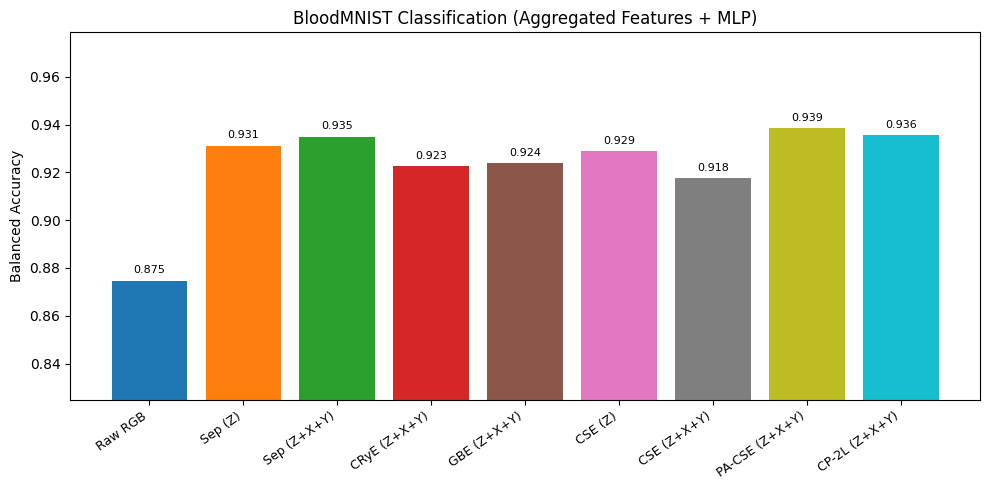

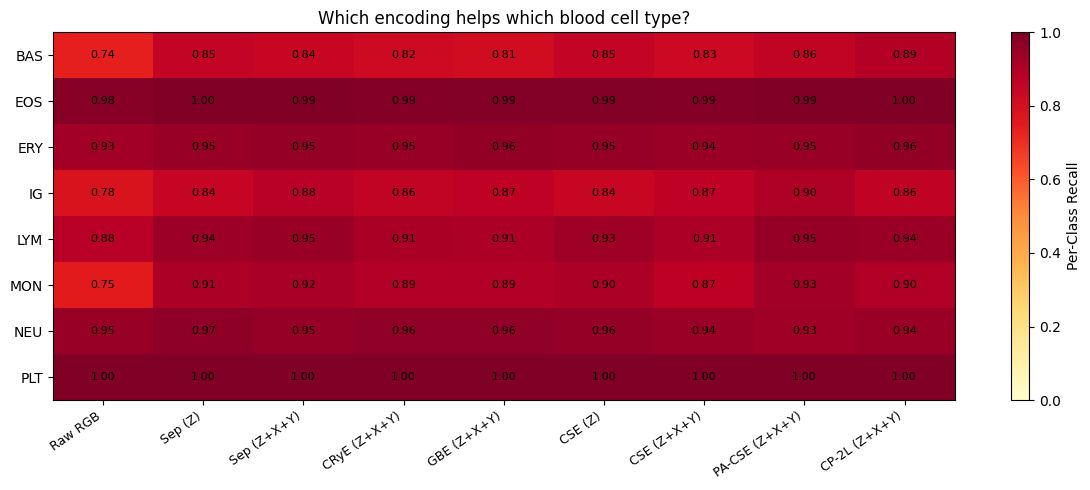

In [8]:
# ==================================================================
# Visualization: bar chart + per-class heatmap
# ==================================================================
scheme_order = ['Raw RGB','Sep (Z)','Sep (Z+X+Y)','CRyE (Z+X+Y)','GBE (Z+X+Y)',
                'CSE (Z)','CSE (Z+X+Y)','PA-CSE (Z+X+Y)','CP-2L (Z+X+Y)']
scheme_order = [s for s in scheme_order if s in results]

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bas = [results[s]['ba'] for s in scheme_order]
colors = plt.cm.tab10(np.linspace(0, 1, len(scheme_order)))
bars = ax.bar(range(len(scheme_order)), bas, color=colors)
ax.set_xticks(range(len(scheme_order)))
ax.set_xticklabels(scheme_order, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Balanced Accuracy')
ax.set_title('BloodMNIST Classification (Aggregated Features + MLP)')
for bar, v in zip(bars, bas):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=8)
ax.set_ylim(min(bas)-0.05, max(bas)+0.04)
plt.tight_layout()
plt.show()

# Per-class heatmap
rec_matrix = np.array([results[s]['rec'] for s in scheme_order])
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(rec_matrix.T, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(scheme_order)))
ax.set_xticklabels(scheme_order, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(class_names)))
ax.set_yticklabels(class_names)
for i in range(len(class_names)):
    for j in range(len(scheme_order)):
        ax.text(j, i, f'{rec_matrix[j,i]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='Per-Class Recall')
ax.set_title('Which encoding helps which blood cell type?')
plt.tight_layout()
plt.show()

In [9]:
# ==================================================================
# Train model + predict ALL test images (single source of truth)
# ==================================================================
import torch, torch.nn as nn

scheme_name = 'Sep (Z+X+Y)'
Xtr, Xte = schemes[scheme_name]
Atr, Ate = agg(Xtr), agg(Xte)
mu_sc, std_sc = Atr.mean(0), Atr.std(0) + 1e-8

torch.manual_seed(0)
d = Atr.shape[1]
model = nn.Sequential(
    nn.Linear(d, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
    nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(128, len(class_names))
).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=200)
loss_fn = nn.CrossEntropyLoss()
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(
        torch.tensor((Atr - mu_sc) / std_sc, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)),
    batch_size=512, shuffle=True)
model.train()
for ep in range(200):
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
    sched.step()

model.eval()
with torch.no_grad():
    Xt = torch.tensor((Ate - mu_sc) / std_sc, dtype=torch.float32).to(device)
    logits_all = model(Xt)
    all_preds = logits_all.argmax(1).cpu().numpy()
    all_probs = torch.softmax(logits_all, 1).cpu().numpy()

acc = (all_preds == y_test).mean()
wrong_idx = np.where(all_preds != y_test)[0]
print(f"Model trained. ACC={acc:.4f}, Misclassified: {len(wrong_idx)}/{len(y_test)}")

Model trained. ACC=0.9570, Misclassified: 147/3421


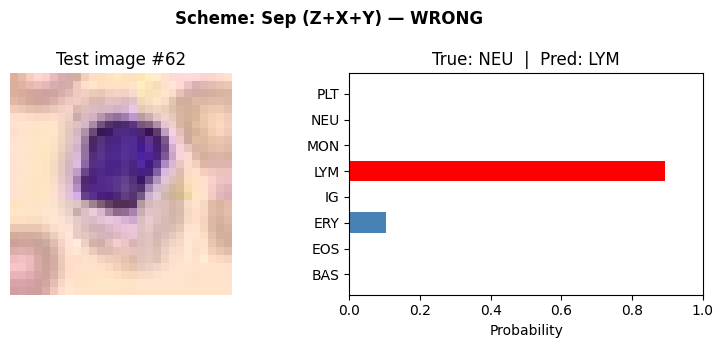

In [10]:
# ==================================================================
# Inspect single test image (change idx to explore)
# ==================================================================
idx = 62  # change this to explore

img = X_test[idx]
true_lbl = y_test[idx]
pred_lbl = all_preds[idx]
probs = all_probs[idx]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(img)
axes[0].set_title(f"Test image #{idx}")
axes[0].axis('off')

colors = ['green' if i == true_lbl else 'red' if i == pred_lbl else 'steelblue'
          for i in range(len(class_names))]
axes[1].barh(class_names, probs, color=colors)
axes[1].set_xlabel('Probability')
axes[1].set_title(f"True: {class_names[true_lbl]}  |  Pred: {class_names[pred_lbl]}")
axes[1].set_xlim(0, 1)

status = "CORRECT" if pred_lbl == true_lbl else "WRONG"
fig.suptitle(f"Scheme: {scheme_name} — {status}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Misclassified: 147 / 3421 (4.3%)

Top confusions (true -> predicted):
    NEU -> IG     22
     IG -> MON    22
     IG -> NEU    16
    BAS -> IG     15
     IG -> BAS    10
    MON -> IG     8
    MON -> LYM    7
    ERY -> IG     6
     IG -> LYM    5
     IG -> ERY    4
    LYM -> ERY    3
    MON -> BAS    3
    NEU -> LYM    2
    LYM -> IG     2
     IG -> EOS    2


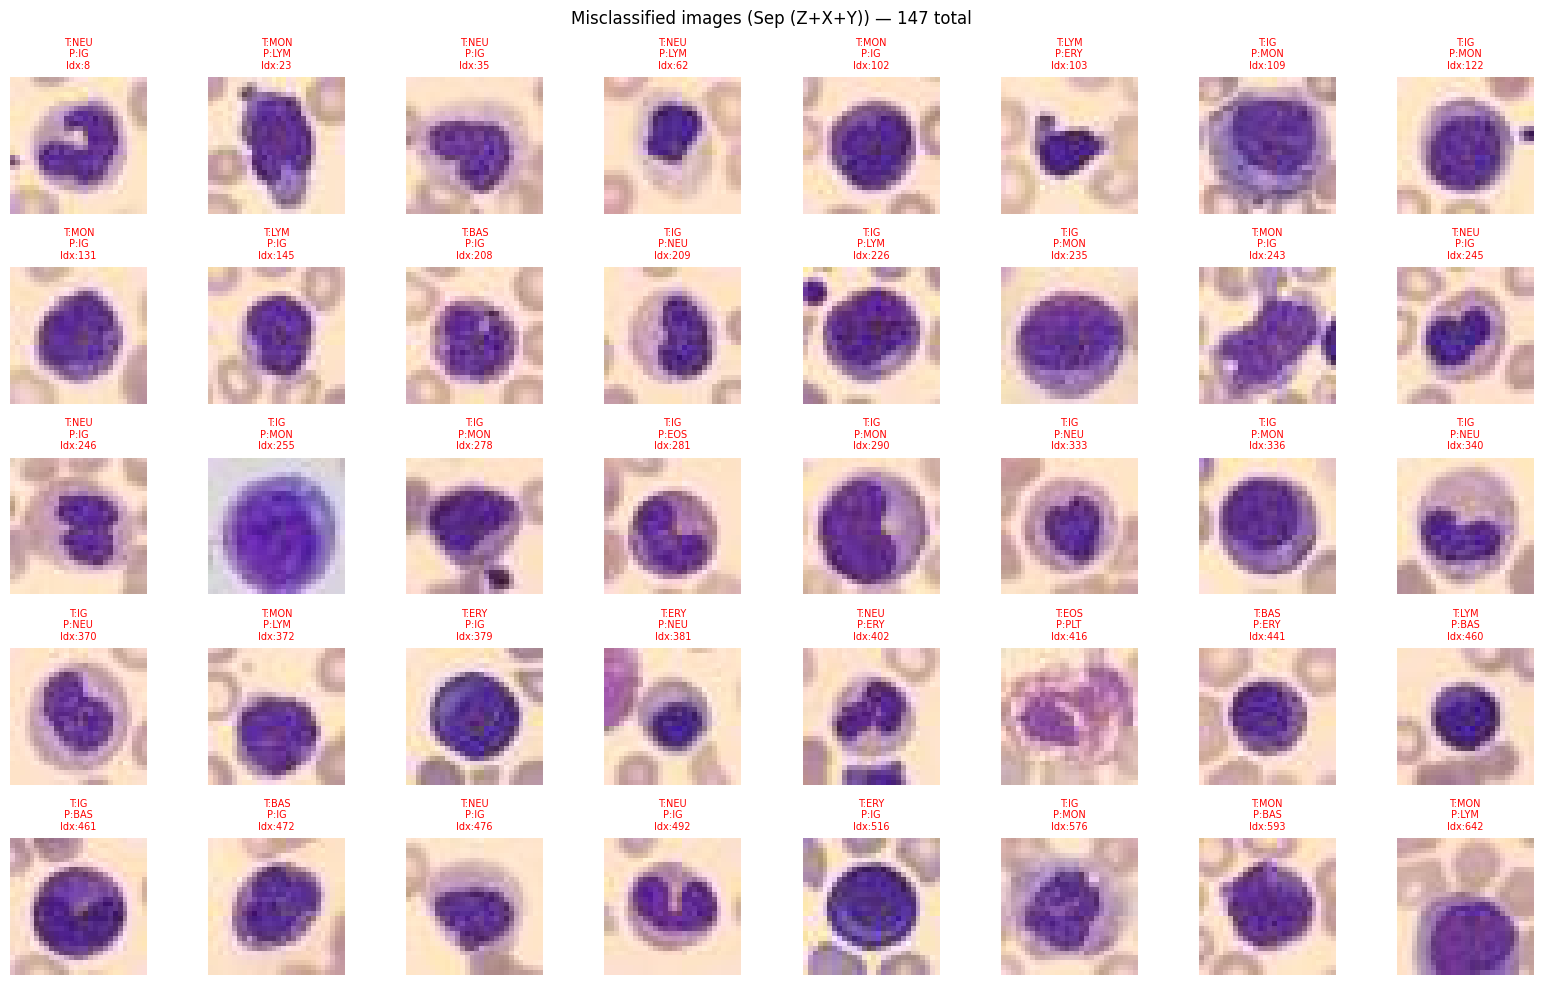

In [11]:
# ==================================================================
# All misclassified images
# ==================================================================
from collections import Counter

print(f"Misclassified: {len(wrong_idx)} / {len(y_test)} ({100*len(wrong_idx)/len(y_test):.1f}%)")
print(f"\nTop confusions (true -> predicted):")
confusion = Counter((class_names[y_test[i]], class_names[all_preds[i]]) for i in wrong_idx)
for (tc, pc), count in confusion.most_common(15):
    print(f"  {tc:>5s} -> {pc:<5s}  {count}")

n_show = min(len(wrong_idx), 40)
cols = 8
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 2*rows))
axes = axes.ravel()

for i in range(n_show):
    ax = axes[i]
    wi = wrong_idx[i]
    ax.imshow(X_test[wi])
    ax.set_title(f"T:{class_names[y_test[wi]]}\nP:{class_names[all_preds[wi]]}\nIdx:{wi}",
                fontsize=7, color='red')
    ax.axis('off')

for i in range(n_show, len(axes)):
    axes[i].axis('off')

fig.suptitle(f"Misclassified images ({scheme_name}) — {len(wrong_idx)} total", fontsize=12)
plt.tight_layout()
plt.show()